In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("Kyiv_flats_ML.csv")
print(df.shape)
print("Пропусків:", df.isna().sum().sum())

(9970, 77)
Пропусків: 0


In [3]:
TARGET = "price"


def build_feature_frame(df: pd.DataFrame):
    feature_cols = [c for c in df.columns if c != TARGET]
    X = df[feature_cols].astype({c: "float64" for c in df[feature_cols].select_dtypes("bool").columns})
    y = np.log1p(df[TARGET].astype(float))
    return X, y

In [4]:
def drop_constant_columns(X: pd.DataFrame) -> pd.DataFrame:
    constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if constant_cols:
        print(f"  Прибрано {len(constant_cols)} константних колонок: {constant_cols}")
    return X.drop(columns=constant_cols)


def prune_by_vif(X: pd.DataFrame, thresh: float = 10.0) -> list[str]:
    X = drop_constant_columns(X).astype(float)
    X_const = add_constant(X, has_constant="add")

    while X_const.shape[1] > 2:
        vifs = pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns,
        ).drop("const")
        worst = vifs.idxmax()
        if vifs[worst] < thresh:
            break
        print(f"  Дропаю '{worst}' (VIF={vifs[worst]:.1f})")
        X_const = X_const.drop(columns=[worst])

    kept = [c for c in X_const.columns if c != "const"]
    print(f"  Лишилось {len(kept)} ознак після VIF-відбору")
    return kept


def evaluate(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> dict:
    """Ціль — log(price), де price вже $/м². MAPE/MAE/RMSE рахуються на
    відновленому $/м² (не на загальній ціні об'єкта — тут її й нема,
    оскільки area вже не бере участі в цілі)."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return {
        "R2": r2_score(y_true_log, y_pred_log),
        "MAE_$/m2": mean_absolute_error(y_true, y_pred),
        "RMSE_$/m2": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE_%": (np.abs((y_true - y_pred) / y_true).mean()) * 100,
    }


RF_GRID = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 8, 12, 20],
    "min_samples_leaf": [1, 2, 4],
}
HGB_GRID = {
    "max_iter": [200, 400, 600],
    "max_depth": [None, 4, 8],
    "learning_rate": [0.03, 0.06, 0.1],
}


def fit_variant(model_name, X_train, X_test, y_train, y_test, cols, fixed_params=None):
    X_train_c, X_test_c = X_train[cols], X_test[cols]

    if model_name == "Ridge":
        scaler = StandardScaler()
        Xs_train_c = scaler.fit_transform(X_train_c)
        Xs_test_c = scaler.transform(X_test_c)
        if fixed_params is not None:
            model = RidgeCV(alphas=[fixed_params["alpha_"]]).fit(Xs_train_c, y_train)
        else:
            model = RidgeCV(alphas=np.logspace(-2, 3, 30)).fit(Xs_train_c, y_train)
        X_test_final = Xs_test_c

    elif model_name == "RandomForest":
        if fixed_params is not None:
            model = RandomForestRegressor(random_state=RANDOM_STATE, **fixed_params).fit(X_train_c, y_train)
        else:
            search = GridSearchCV(
                RandomForestRegressor(random_state=RANDOM_STATE),
                RF_GRID, cv=5, scoring="r2", n_jobs=-1,
            )
            search.fit(X_train_c, y_train)
            model = search.best_estimator_
        X_test_final = X_test_c

    else:  # HistGradientBoosting
        if fixed_params is not None:
            model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **fixed_params).fit(X_train_c, y_train)
        else:
            search = GridSearchCV(
                HistGradientBoostingRegressor(random_state=RANDOM_STATE),
                HGB_GRID, cv=5, scoring="r2", n_jobs=-1,
            )
            search.fit(X_train_c, y_train)
            model = search.best_estimator_
        X_test_final = X_test_c

    metrics = evaluate(y_test.values, model.predict(X_test_final))
    return model, X_test_final, metrics


def get_model_params(model_name: str, model) -> dict:
    if model_name == "Ridge":
        return {"alpha_": model.alpha_}
    if model_name == "RandomForest":
        return {k: v for k, v in model.get_params().items()
                if k in ("n_estimators", "max_depth", "min_samples_leaf")}
    return {k: v for k, v in model.get_params().items()
            if k in ("max_iter", "max_depth", "learning_rate")}

--- Навчання на ПОВНОМУ наборі ознак (без VIF) ---

--- Результати на test (повний набір ознак) ---
                            R2    MAE_$/m2   RMSE_$/m2     MAPE_%
Ridge                 0.633197  340.438769  484.793350  18.572006
RandomForest          0.774473  246.116459  357.837623  13.788274
HistGradientBoosting  0.788988  241.774178  349.461509  13.388018

>>> Найкраща модель: HistGradientBoosting

--- VIF-відбір (лише для feature importance, на train) ---
  Дропаю 'autonomy_heat_unknown' (VIF=inf)
  Дропаю 'autonomy_water_unknown' (VIF=inf)
  Дропаю 'autonomy_net_unknown' (VIF=inf)
  Дропаю 'house_type_special_project' (VIF=28.3)
  Дропаю 'area' (VIF=14.3)
  Дропаю 'lon' (VIF=13.4)
  Дропаю 'year_of_building' (VIF=13.3)
  Дропаю 'autonomy_power_unknown' (VIF=11.7)
  Лишилось 68 ознак після VIF-відбору

R² HistGradientBoosting: повний набір ознак = 0.789, після VIF-відбору = 0.765
MAPE_% $/м² після VIF-відбору: 14.3%


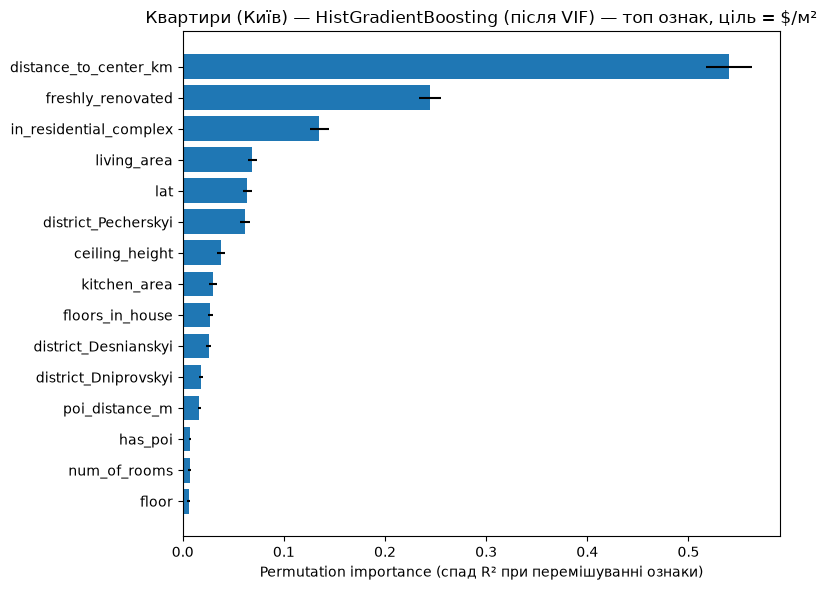

In [5]:
def train_and_compare(df: pd.DataFrame, vif_thresh: float = 10.0):
    X, y = build_feature_frame(df)
    idx_train, idx_test = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE)

    X_train, X_test = X.loc[idx_train].copy(), X.loc[idx_test].copy()
    y_train, y_test = y.loc[idx_train], y.loc[idx_test]

    full_cols = list(X.columns)

    print("--- Навчання на ПОВНОМУ наборі ознак (без VIF) ---")
    results, fitted = {}, {}
    for name in ["Ridge", "RandomForest", "HistGradientBoosting"]:
        model, _, metrics = fit_variant(name, X_train, X_test, y_train, y_test, full_cols)
        results[name] = metrics
        fitted[name] = model

    results_df = pd.DataFrame(results).T
    print("\n--- Результати на test (повний набір ознак) ---")
    print(results_df)

    best_name = results_df["MAPE_%"].idxmin()
    print(f"\n>>> Найкраща модель: {best_name}")

    print("\n--- VIF-відбір (лише для feature importance, на train) ---")
    kept_cols = prune_by_vif(X_train, thresh=vif_thresh)

    best_model_pruned, X_test_pruned, pruned_metrics = fit_variant(
        best_name, X_train, X_test, y_train, y_test, kept_cols
    )
    print(f"\nR² {best_name}: повний набір ознак = {results_df.loc[best_name, 'R2']:.3f}, "
          f"після VIF-відбору = {pruned_metrics['R2']:.3f}")
    print(f"MAPE_% $/м² після VIF-відбору: {pruned_metrics['MAPE_%']:.1f}%")

    perm = permutation_importance(
        best_model_pruned, X_test_pruned, y_test, n_repeats=20,
        random_state=RANDOM_STATE, scoring="r2", n_jobs=-1,
    )
    importance_df = (
        pd.DataFrame({"feature": kept_cols, "importance": perm.importances_mean,
                      "std": perm.importances_std})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    top_n = importance_df.head(15)
    plt.figure(figsize=(8, 6))
    plt.barh(top_n["feature"][::-1], top_n["importance"][::-1], xerr=top_n["std"][::-1])
    plt.xlabel("Permutation importance (спад R² при перемішуванні ознаки)")
    plt.title(f"Квартири (Київ) — {best_name} (після VIF) — топ ознак, ціль = $/м²")
    plt.tight_layout()
    plt.show()

    return {
        "results_df": results_df,
        "best_name": best_name,
        "best_model_pruned": best_model_pruned,
        "fixed_params": get_model_params(best_name, best_model_pruned),
        "importance_df": importance_df,
        "kept_cols": kept_cols,
    }


result = train_and_compare(df)

In [6]:
result["importance_df"].head(15)

,feature,importance,std
0,distance_to_center_km,0.540077,0.022298
1,freshly_renovated,0.244550,0.010868
2,in_residential_complex,0.135182,0.009773
3,living_area,0.068864,0.004448
4,lat,0.063952,0.004275
5,district_Pecherskyi,0.061816,0.005089
6,ceiling_height,0.037465,0.003908
7,kitchen_area,0.030111,0.003890
8,floors_in_house,0.027361,0.002705
9,district_Desnianskyi,0.025725,0.002479


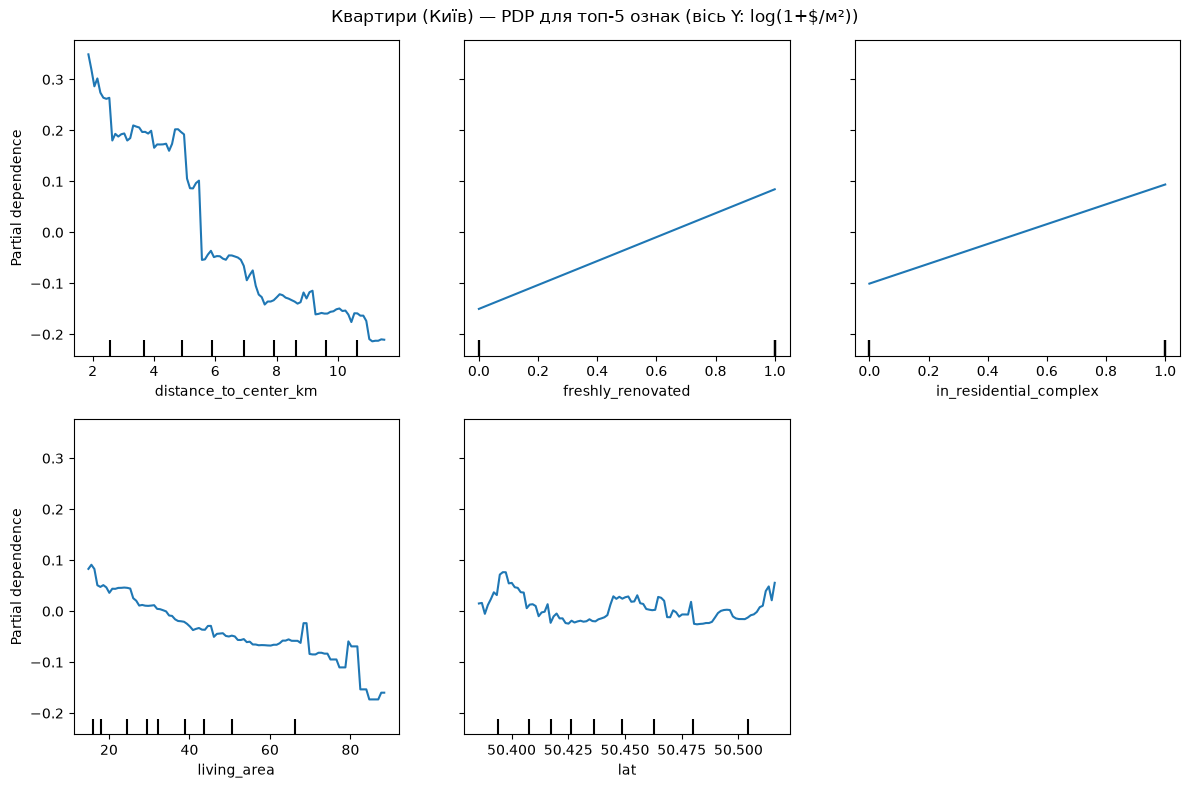

In [7]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.pipeline import make_pipeline

TOP_N_PDP = 5
top_features = result["importance_df"]["feature"].head(TOP_N_PDP).tolist()

X, y = build_feature_frame(df)
idx_train, _ = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE)
X_train = X.loc[idx_train].copy()

kept_cols = result["kept_cols"]
X_train_kept = X_train[kept_cols].astype(float)

if result["best_name"] == "Ridge":
    # PDP подає ознаки на вхід моделі як є — Ridge навчався на
    # масштабованих ознаках, тож обгортаємо scaler+модель у Pipeline,
    # щоб вісь X показувала реальні одиниці (км/$/м² тощо), а не
    # стандартизовані значення
    scaler_for_pdp = StandardScaler().fit(X_train_kept)
    pdp_estimator = make_pipeline(scaler_for_pdp, result["best_model_pruned"])
else:
    pdp_estimator = result["best_model_pruned"]

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    pdp_estimator, X_train_kept, features=top_features, ax=ax,
)
plt.suptitle(f"Квартири (Київ) — PDP для топ-{TOP_N_PDP} ознак (вісь Y: log(1+$/м²))")
plt.tight_layout()
plt.show()

In [8]:
def cross_validate_best(df: pd.DataFrame, best_name: str, kept_cols: list[str],
                         fixed_params: dict, n_splits: int = 5):
    X, y = build_feature_frame(df)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_metrics = []

    for fold_i, (tr_idx, val_idx) in enumerate(kf.split(df.index), start=1):
        idx_tr = df.index[tr_idx]
        idx_val = df.index[val_idx]

        X_tr, X_val = X.loc[idx_tr], X.loc[idx_val]
        y_tr, y_val = y.loc[idx_tr], y.loc[idx_val]

        cols = [c for c in kept_cols if c in X_tr.columns]
        _, _, metrics = fit_variant(best_name, X_tr, X_val, y_tr, y_val, cols, fixed_params=fixed_params)
        metrics["fold"] = fold_i
        fold_metrics.append(metrics)

    cv_df = pd.DataFrame(fold_metrics).set_index("fold")
    summary = cv_df.agg(["mean", "std"])
    print(cv_df)
    print("\n--- Підсумок по фолдах ---")
    print(summary)
    return cv_df


cv_results = cross_validate_best(
    df, result["best_name"], result["kept_cols"], result["fixed_params"],
)

            R2    MAE_$/m2   RMSE_$/m2     MAPE_%
fold                                             
1     0.764673  257.280194  376.194278  14.254909
2     0.777915  243.198015  339.110973  14.138750
3     0.754521  266.120099  393.821650  14.542225
4     0.768896  256.867115  384.810370  13.880884
5     0.781981  262.091654  381.610338  14.267875

--- Підсумок по фолдах ---
            R2    MAE_$/m2   RMSE_$/m2     MAPE_%
mean  0.769597  257.111415  375.109522  14.216929
std   0.010892    8.654912   21.116244   0.239214


In [9]:
def save_production_pipeline(df: pd.DataFrame, best_name: str, kept_cols: list[str],
                             fixed_params: dict, out_file: str):
    X, y = build_feature_frame(df)
    cols = [c for c in kept_cols if c in X.columns]
    X_c = X[cols]

    scaler = None
    if best_name == "Ridge":
        scaler = StandardScaler().fit(X_c)
        model = RidgeCV(alphas=[fixed_params["alpha_"]]).fit(scaler.transform(X_c), y)
    elif best_name == "RandomForest":
        model = RandomForestRegressor(random_state=RANDOM_STATE, **fixed_params).fit(X_c, y)
    else:
        model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **fixed_params).fit(X_c, y)

    artifact = {
        "model_name": best_name,
        "model": model,
        "scaler": scaler,
        "feature_cols": cols,
    }
    joblib.dump(artifact, out_file)
    print(f"Збережено: {out_file}")
    return artifact


def predict_new_object(artifact: dict, new_row: dict) -> float:
    """new_row — dict з уже one-hot закодованими ознаками (включно з
    district_* прапорцями, як у df). Повертає прогнозовану ціну за м² в $."""
    row = pd.Series(new_row)
    X_new = pd.DataFrame([row])[artifact["feature_cols"]].astype(float)
    if artifact["scaler"] is not None:
        X_new = artifact["scaler"].transform(X_new)

    pred_log = artifact["model"].predict(X_new)[0]
    return float(np.expm1(pred_log))


artifact = save_production_pipeline(
    df, result["best_name"], result["kept_cols"], result["fixed_params"],
    out_file="flats_kyiv_model_pipeline.joblib",
)

Збережено: flats_kyiv_model_pipeline.joblib
